In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np

import matplotlib.pyplot as plt

from scipy.signal import welch

import loadmat as lm

# 1 Data processing
## 1.1 Load data

In [ ]:
data = lm.loadmat('SSVEP.mat')['data']

# 0 = no stimulation, 1 = stimulation
sig = np.asarray(data['signal'], dtype=float)   # (nbSamples, nbChannels)
cue = np.asarray(data['cue']).ravel()           # (nbSamples)

fs = 256  # sampling rate in Hz

# Electrodes as per task description
electrodes = {0: 'F3', 1: 'Fz', 2: 'F4', 3: 'C4', 4: 'Cz', 5: 'C3',
              6: 'P3', 7: 'Pz', 8: 'P4', 9: 'O2', 10: 'Oz', 11: 'O1'}
n_ch = len(electrodes)

print(f'signal: {sig.shape[0]} samples x {n_ch} channels')
print(f'fs:     {fs} Hz')
print(f'cue:    {np.count_nonzero(cue)} samples of stimulation')

signal: 63603 samples x 12 channels
fs:     256 Hz
cue:    38400 samples of stimulation


## 1.2 Trial segmentation

In [ ]:
# Stimulation trials are the contiguous runs of cue == 1
idx = np.flatnonzero(cue == 1)
trials = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)

print(f'trials: {len(trials)}')
print(f'trial length: {len(trials[0])} samples ({len(trials[0]) / fs:.1f} s)')

trials: 10
trial length: 3840 samples (15.0 s)


# 2 Spectral analysis
## 2.1 Channel selection

frequency resolution: 0.0667 Hz
selected channels: ['O2', 'Oz', 'O1']


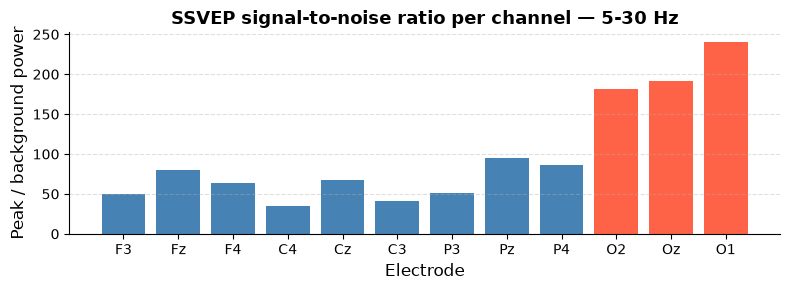

In [ ]:
# We expect the flicker response in the 5-30 Hz band
band = (5, 30)

# Calculate periodogram
def calc_periodogram(t, chans=slice(None), nperseg=None):
    f, p = welch(sig[t][:, chans], fs=fs, nperseg=nperseg or len(t), axis=0)
    return f, p

# (nbTrials, nbFreqs, nbChannels)
f, _ = calc_periodogram(trials[0])
psd = np.stack([calc_periodogram(t)[1] for t in trials])

mask = (f >= band[0]) & (f <= band[1])
fb = f[mask]
print(f'frequency resolution: {f[1] - f[0]:.4f} Hz')

# SSVEP is stems from visual cortex, so keep occipital electrodes
occ = [ch for ch, name in electrodes.items() if name.startswith('O')]
print('selected channels:', [electrodes[ch] for ch in occ])

# Signal-to-noise for all channels
snr = np.array([np.mean(psd[:, mask, ch].max(1) / np.median(psd[:, mask, ch], 1))
                for ch in range(n_ch)])

# Plot SNR of every channel
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(n_ch), snr, color=['tomato' if ch in occ else 'steelblue' for ch in range(n_ch)])
ax.set_xticks(range(n_ch), list(electrodes.values()))
ax.set_xlabel('Electrode', fontsize=12)
ax.set_ylabel('Peak / background power', fontsize=12)
ax.set_title(f'SSVEP signal-to-noise ratio per channel — {band[0]}-{band[1]} Hz',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 2.2 Flicker frequencies

dominant frequency per trial (Hz): [ 8.07 14.13 14.13 14.13  8.07  8.07 14.13 14.13  8.07  8.07]

freq_slow = 8.07 Hz (yes)
freq_fast = 14.13 Hz (no)


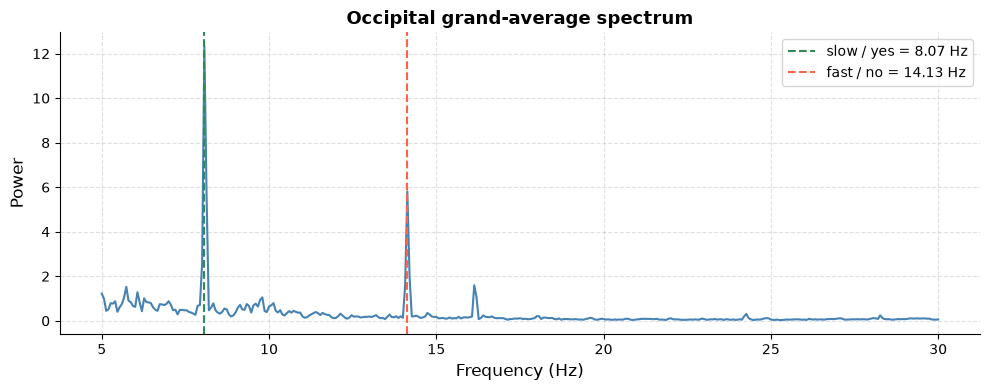

In [ ]:
# Spectrum per trial, averaged over the selected channels
spectra = psd[:, mask][:, :, occ].mean(-1)

# Find dominant frequencies, corresponds to yes/no
dom = fb[spectra.argmax(axis=1)]
print('dominant frequency per trial (Hz):', np.round(dom, 2))

freq_slow, freq_fast = np.unique(dom)
print(f'\nfreq_slow = {freq_slow:.2f} Hz (yes)')
print(f'freq_fast = {freq_fast:.2f} Hz (no)')

# Plot the spectrum
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fb, spectra.mean(axis=0), color='steelblue', linewidth=1.5)
ax.axvline(freq_slow, color='seagreen', linestyle='--', linewidth=1.5,
           label=f'slow / yes = {freq_slow:.2f} Hz')
ax.axvline(freq_fast, color='tomato', linestyle='--', linewidth=1.5,
           label=f'fast / no = {freq_fast:.2f} Hz')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power', fontsize=12)
ax.set_title('Occipital grand-average spectrum', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 2.3 Pre-stimulation control

baseline length: 5.0 s
stimulation during baseline: 0 samples


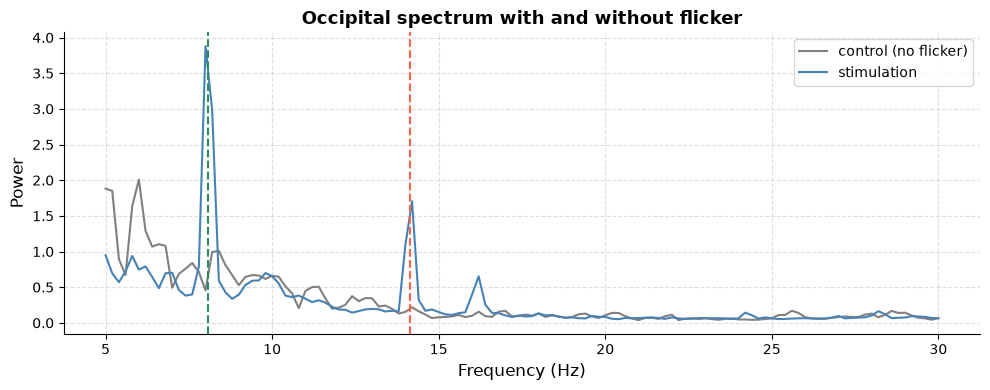

In [ ]:
# First 5s without flicker, serves as control
baseline = [np.arange(t[0] - 5 * fs, t[0]) for t in trials]
print('baseline length:', len(baseline[0]) / fs, 's')
print('stimulation during baseline:', np.count_nonzero([cue[b] for b in baseline]), 'samples')

# Equal window lengths, otherwise the two spectra are not comparable
nperseg = 5 * fs
f_c, _ = calc_periodogram(baseline[0], occ, nperseg)
mask_c = (f_c >= band[0]) & (f_c <= band[1])
fb_c = f_c[mask_c]

# Base and stimulation spectra
spec_base = np.stack([calc_periodogram(b, occ, nperseg)[1][mask_c].mean(-1) for b in baseline])
spec_stim = np.stack([calc_periodogram(t, occ, nperseg)[1][mask_c].mean(-1) for t in trials])

# Plot both spectra
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fb_c, spec_base.mean(axis=0), color='grey', linewidth=1.5, label='control (no flicker)')
ax.plot(fb_c, spec_stim.mean(axis=0), color='steelblue', linewidth=1.5, label='stimulation')
ax.axvline(freq_slow, color='seagreen', linestyle='--', linewidth=1.5)
ax.axvline(freq_fast, color='tomato', linestyle='--', linewidth=1.5)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power', fontsize=12)
ax.set_title('Occipital spectrum with and without flicker', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 3 Decoding
## 3.1 Answers per trial

In [ ]:
# Assign trials to the closer of the two flicker frequencies
answers = ['yes' if abs(d - freq_slow) <= abs(d - freq_fast) else 'no' for d in dom]

print('\nanswers:', ' - '.join(answers))


answers: yes - no - no - no - yes - yes - no - no - yes - yes


## 3.2 Evidence per trial

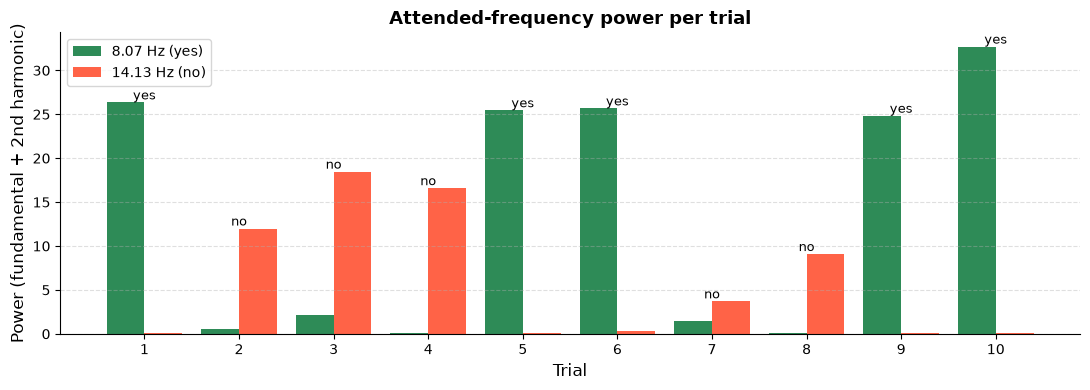

In [ ]:
# Calculate power at the base plus the 2nd harmonic frequency
def ssvep_power(spectrum, freq):
    return sum(spectrum[np.argmin(np.abs(fb - h))] for h in (freq, 2 * freq) if h <= fb[-1])

# Calculate evidence for "no" and "yes" frequencies
p_slow = [ssvep_power(s, freq_slow) for s in spectra]
p_fast = [ssvep_power(s, freq_fast) for s in spectra]

# Plot both frequencies side by side per trial
x = np.arange(1, len(trials) + 1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, p_slow, 0.4, color='seagreen', label=f'{freq_slow:.2f} Hz (yes)')
ax.bar(x + 0.2, p_fast, 0.4, color='tomato', label=f'{freq_fast:.2f} Hz (no)')
for k, a in enumerate(answers):
    ax.text(x[k], max(p_slow[k], p_fast[k]), a, ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Power (fundamental + 2nd harmonic)', fontsize=12)
ax.set_title('Attended-frequency power per trial', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 3.3 Trial spectra

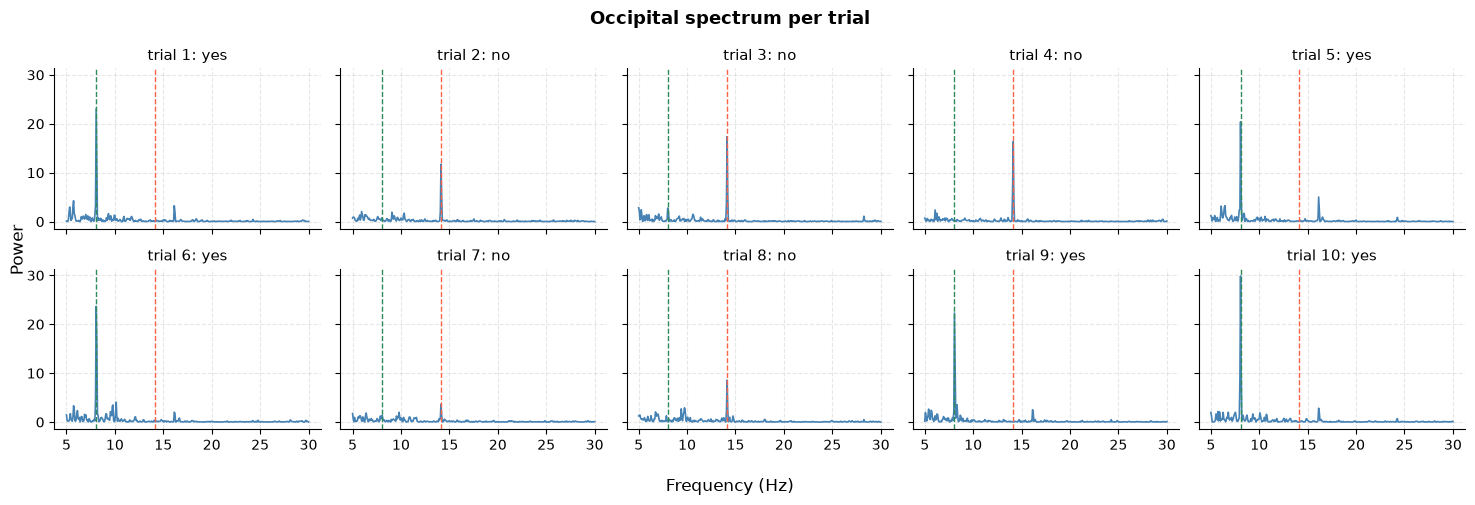

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    ax.plot(fb, spectra[k], color='steelblue', linewidth=1.2)
    ax.axvline(freq_slow, color='seagreen', linestyle='--', linewidth=1)
    ax.axvline(freq_fast, color='tomato', linestyle='--', linewidth=1)
    ax.set_title(f'trial {k + 1}: {answers[k]}', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)

fig.supxlabel('Frequency (Hz)', fontsize=12)
fig.supylabel('Power', fontsize=12)
fig.suptitle('Occipital spectrum per trial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()